# Optimize incident flux

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import festim as F

from festim_permeation_fit.optimize import optimize_flux_without_output
from festim_permeation_fit.piecewise import compress_piecewise

print(F.__version__)

/Users/bintang/miniforge3/envs/festim-permeation-fit/lib/python3.10/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


1.4.1.post1


In [ ]:
shot = 34320
date = 170112
filename = '34320_PDP8_calibrated_f1--2_f2-1.0_winsma-30_winsg1-71_winsg2-7_w2-range310_s5.txt'

# 05_calc_ku/170112/ku_calculator_PP8_34319.ipynb, after kink
ku = 1.1e-32
kd = 5.0e-31

# 04_check_concentration
initial_perm = 8.54e+14
initial_solute = 4.13e+22

# Settings
dt = 2 # s
calc_time = 300 # s
discharge_start = 1.5 # s
inc_amp = 1e16
ver = f"PP8_{shot}_ku-{ku}"

## Plot of Permeation Data

- xx, yy
    - Full shot data
- ax, ay
    - Analysis range (including initial flux consideration)
- bx, by
    - Discharge duration (FESTIM calculation range)

In [3]:
df = pd.read_csv(f'../../data/calibrated/{date}/{filename}', sep=r'\s+', header=None)

num_cols = df.select_dtypes('number').columns

x = df[num_cols[0]]
y = df[num_cols[1]]

xx = np.linspace(x.min(),x.max(),len(x))
fy = interp1d(x,y)
yy = fy(xx)

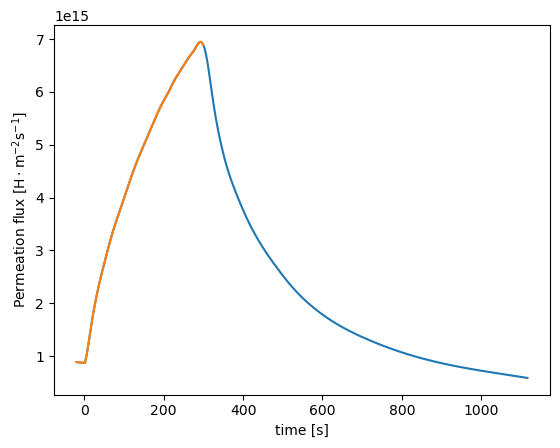

In [4]:
cut = xx[-1] - 20

ind_a = np.where(xx < cut)
ax, ay = (xx[ind_a], yy[ind_a]+initial_perm)

ind_b = np.where((ax < calc_time))
bx, by = (ax[ind_b], ay[ind_b])

# plt.plot(xx, yy)
plt.plot(ax, ay,)
plt.plot(bx, by,)

plt.xlabel('time [s]')
plt.ylabel(r'Permeation flux [$\mathrm{H} \cdot \mathrm{m}^{-2} \mathrm{s}^{-1}$]')
plt.show()

## FESTIM Settings

Every FESTIM model is represented by a `Simulation` object. Here, we give it the name `my_model`

In [5]:
my_model = F.Simulation()

### Mesh

FESTIM simulations need a mesh. FESTIM provides support for simple 1D meshes.

In [6]:
my_model.mesh = F.MeshFromVertices(
    vertices=np.linspace(0, 2e-5, num=301)
)

### Diffusion Coefficient

`Material` objects hold the materials properties like diffusivity and solubility.

Here we only need the diffusivity defined as an Arrhenius law:

$$
    D = D_0 \exp{(-E_D/k_B T)}
$$

where $k_B$ is the Boltzmann constant in eV/K and $T$ is the temperature in K. From this, the pre-exponential coefficient, $D_0$ in m<sup>2</sup>/s, and the diffusion actiavtion energy, $E_D$ in eV are needed.

In [7]:
my_model.materials = F.Material(id=1, D_0=2.9e-8, E_D=0.048) # m^2/s

### Membrane Temperature

In [8]:
my_model.T = 573 # K

### Boundary conditions & source

``surfaces`` is a list of surfaces ids (in 1D, `1` is left and `2` is right).

- Upstream Surface (Plasma-Facing Side)
  - Hydrogen Atoms from Plasma (FluxBC)
  - Hydrogen Molecules Released via Recombination (RecombinationFlux)
- Downstream Surface (Vacuum Side)
  - Hydrogen Molecules Released via Recombination (RecombinationFlux)

In [9]:
# Defined in optimize_flux() (src/festim_permeation_fit/optimize.py)

# my_model.boundary_conditions = [
#     F.FluxBC(surfaces=1, value=flux_expr, field="solute"),
#     F.RecombinationFlux(surfaces=1, Kr_0=ku, E_Kr=0, order=2),
#     F.RecombinationFlux(surfaces=2, Kr_0=kd, E_Kr=0, order=2),
# ]

### Settings

With `Settings` we set the main solver parameters.
- `absolute_tolerance`: the absolute tolerance of the Newton solver.
- `relative_tolerance`: the relative tolerance of the Newton solver.
- `final_time`: since we want to solve a transient problem, we need to set the final time.

In [10]:
my_model.settings = F.Settings(
    absolute_tolerance=1e10,
    relative_tolerance=1e-10,
    final_time=int((ax[-1] // dt) * dt)  # s
)

### Initial Concentration

In [11]:
my_model.initial_conditions = [
    F.InitialCondition(value=initial_solute, field="solute")
]

### Exports

In [12]:
derived_quantities = F.DerivedQuantities(
    [F.HydrogenFlux(surface=2)],  # Permeation Flux on the Vacuum Side
    show_units=True,
)

my_model.exports = [derived_quantities]

### Stepsize

Since we are solving a transient problem, we need to set a ``Stepsize``.

In [13]:
my_model.dt = F.Stepsize(initial_value=dt)

## Optimization

### Settings

In [14]:
Nt = int(ax[-1] // dt)
calc_point = int(calc_time // dt)
fixed_point = Nt - calc_point

sample_time = np.arange(start=dt, stop=bx[-1]+dt, step=dt)
selected_indices = [np.abs(bx - t).argmin() for t in sample_time]

bx_arg = bx[selected_indices]
by_arg = by[selected_indices]

In [15]:
config = {
    'model': my_model,
    'dq': derived_quantities,
    'Nt': Nt,
    'inc_amp': inc_amp,
    'dt': dt,
    'ku': ku,
    'kd': kd
}

### Optimization loop

In [16]:
G_opt = [0] * int(discharge_start/dt)

# --- Optimization loop ---
for i in range(len(G_opt), calc_point) :
    print(f"Optimizing timestep {i+1}/{calc_point}")

    res = minimize(
        optimize_flux_without_output,
        x0=[1.0],  # initial Values
        bounds=[(0, None)],
        args=(G_opt, i, by_arg, config),
        method="L-BFGS-B",
        options={
            "eps": 1e-2,
            "maxiter": 20000,
            "maxfun": 20000,
        }
    )

    G_opt.append(res.x[0])


print("Optimization results:", G_opt)

G_opt += [0] * fixed_point
G_opt = np.array(G_opt)

Optimizing timestep 1/150
Optimizing timestep 2/150
Optimizing timestep 3/150
Optimizing timestep 4/150
Optimizing timestep 5/150
Optimizing timestep 6/150
Optimizing timestep 7/150
Optimizing timestep 8/150
Optimizing timestep 9/150
Optimizing timestep 10/150
Optimizing timestep 11/150
Optimizing timestep 12/150
Optimizing timestep 13/150
Optimizing timestep 14/150
Optimizing timestep 15/150
Optimizing timestep 16/150
Optimizing timestep 17/150
Optimizing timestep 18/150
Optimizing timestep 19/150
Optimizing timestep 20/150
Optimizing timestep 21/150
Optimizing timestep 22/150
Optimizing timestep 23/150
Optimizing timestep 24/150
Optimizing timestep 25/150
Optimizing timestep 26/150
Optimizing timestep 27/150
Optimizing timestep 28/150
Optimizing timestep 29/150
Optimizing timestep 30/150
Optimizing timestep 31/150
Optimizing timestep 32/150
Optimizing timestep 33/150
Optimizing timestep 34/150
Optimizing timestep 35/150
Optimizing timestep 36/150
Optimizing timestep 37/150
Optimizing

In [17]:
incident_opt_piecewise = compress_piecewise(G_opt*inc_amp, F.t, dt)

my_model.boundary_conditions = [
    F.FluxBC(surfaces=1, value=incident_opt_piecewise, field="solute"),
    F.RecombinationFlux(surfaces=1, Kr_0=ku, E_Kr=0, order=2),
    F.RecombinationFlux(surfaces=2, Kr_0=kd, E_Kr=0, order=2),
]

my_model.initialise()
my_model.run()

Defining initial values
Defining variational problem
Defining source terms
Defining boundary conditions
Time stepping...
100.0 %        1.1e+03 s    Elapsed time so far: 0.8 s


## Results

### Plot of fitting results

In [18]:
time = np.array(derived_quantities.t)
permeation_opt = np.abs(derived_quantities.filter(surfaces=2).data)
incident_opt = np.array(G_opt*inc_amp)

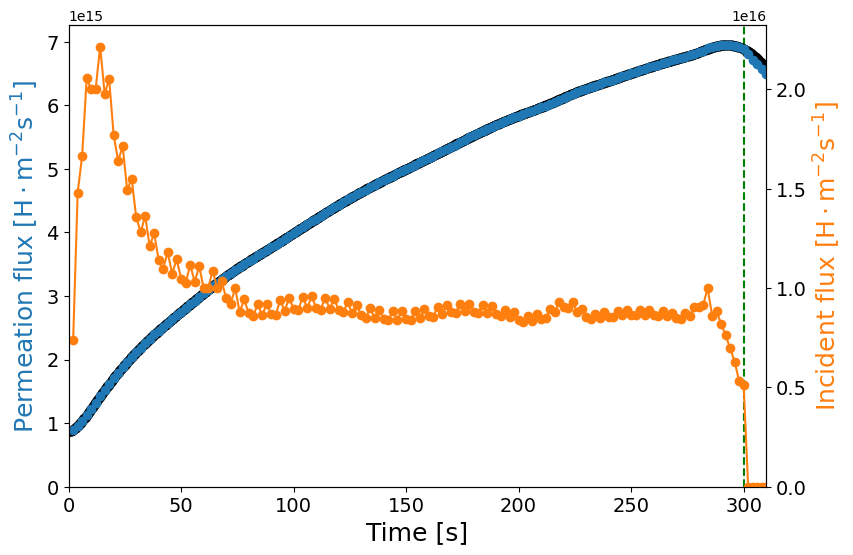

In [19]:
fig, ax1 = plt.subplots(figsize=(9, 6))
ax2 = ax1.twinx()

ax1.axvline(x=calc_time, color='green', linestyle='--', label=f'x={calc_time}')
ax1.plot(ax, ay, 'o-', color='black')
ax1.plot(time, permeation_opt, 'o-', color='tab:blue')
ax2.plot(time, incident_opt, 'o-', color='tab:orange')

ax1.set_xlabel('Time [s]', fontsize=18)

ax1.set_ylabel(r'Permeation flux [$\mathrm{H} \cdot \mathrm{m}^{-2} \mathrm{s}^{-1}$]', color='tab:blue', fontsize=18)
ax2.set_ylabel(r'Incident flux [$\mathrm{H} \cdot \mathrm{m}^{-2} \mathrm{s}^{-1}$]', color='tab:orange', fontsize=18)

ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

ax1.set_xlim(left=0,right=calc_time+10)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
plt.show()

### Output fitting results

In [20]:
time_csv = pd.Series(time)
incident_csv = pd.Series(incident_opt)
permeation_csv = pd.Series(permeation_opt)

filename = f'../../data/optimized/{date}/opt_{ver}.csv'

df = pd.DataFrame({'t(s)': time_csv, 'incident': incident_csv, 'permeation': permeation_csv})

df.to_csv(filename, index=False)

print(f"Saved data to '{filename}'")

Saved data to '../../data/optimized/170112/opt_PP8_34320_ku-1.1e-32.csv'
